<center>
<a href="https://www.umontpellier.fr/"><img src="https://www.umontpellier.fr/wp-content/uploads/2022/10/logo_um_2022_rouge_rvb.svg" width="200"/></a>&nbsp;&nbsp;
<a href="https://economie.edu.umontpellier.fr/"><img src="https://economie.edu.umontpellier.fr/files/2014/12/economie_rvb_2015-300x137.png" width="160"/></a>
</center>

<div align="center">

#  Phase 6 — Machine Learning

| Nom et Prénom | Rôle |
|---|---|
| Randriamisaina Tsiory-Fanomezana | Membre de l'équipe |
| SHIRALI POUR Amir | Membre de l'équipe |

</div>

---
## Objectif

**Tâche 1 — Régression :** prédire `duree_totale_h` (durée de traitement en heures)  
**Tâche 2 — Classification :** prédire `Cause.intervention` (type de sinistre)

**Référence :** [`docs/phase6_machine_learning.md`](../docs/phase6_machine_learning.md)  
**Données :** `data/dataset_complet.csv` — 98 935 × 34 colonnes


---
## Section 0 — Initialisation

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                              accuracy_score, f1_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)

def localiser_racine_du_projet():
    """Remonte l'arborescence jusqu'à trouver la racine du projet."""
    repertoire_courant = Path.cwd()
    while True:
        if any((repertoire_courant / m).exists() for m in ['.git', 'requirements.txt']):
            break
        if repertoire_courant.parent == repertoire_courant:
            break
        repertoire_courant = repertoire_courant.parent
    if Path.cwd() != repertoire_courant:
        os.chdir(repertoire_courant)
    return repertoire_courant.resolve()

REPERTOIRE_RACINE = localiser_racine_du_projet()
sys.path.insert(0, str(REPERTOIRE_RACINE / 'src'))
from utils.dataframe_styler import style_duplicates
print(f" Racine du projet : {REPERTOIRE_RACINE}")

 Racine du projet : /Users/su6i/Documents/DU/Projet Data/projet_big_data_v2


In [2]:
dataset = pd.read_csv('data/dataset_complet.csv', encoding='utf-8')
print(f" Dataset : {dataset.shape[0]:,} lignes × {dataset.shape[1]} colonnes")

 Dataset : 98,935 lignes × 34 colonnes


---
## Section 1 — Préparation des Données

### 1.1 Définition des features et de la cible

In [3]:
# --- Features communes aux deux tâches
FEATURES_NUMERIQUES = [
    'agent_experience_j', 'agent_duree_travail_j', 'agent_temps_travail_pct',
    'delai_survenance_ouverture_j', 'nb_interventions', 'nb_agents_distincts',
    'mois_ouverture'
]

FEATURES_CATEGORIELLES = [
    'agent_lieu_travail', 'agent_contrat', 'agent_population', 'annee_ouverture'
]

TOUTES_FEATURES = FEATURES_NUMERIQUES + FEATURES_CATEGORIELLES

print("Features numériques  :", FEATURES_NUMERIQUES)
print("Features catégorielles:", FEATURES_CATEGORIELLES)
print(f"Total features       : {len(TOUTES_FEATURES)}")

Features numériques  : ['agent_experience_j', 'agent_duree_travail_j', 'agent_temps_travail_pct', 'delai_survenance_ouverture_j', 'nb_interventions', 'nb_agents_distincts', 'mois_ouverture']
Features catégorielles: ['agent_lieu_travail', 'agent_contrat', 'agent_population', 'annee_ouverture']
Total features       : 11


In [4]:
# --- Pipeline de prétraitement (M2 — évite le data leakage)
preprocesseur = ColumnTransformer(transformers=[
    ('numerique',    Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler())
    ]), FEATURES_NUMERIQUES),
    ('categoriel',   Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), FEATURES_CATEGORIELLES),
], remainder='drop')

print(" Pipeline de prétraitement défini")
print("   → Imputation médiane pour les numériques")
print("   → Imputation mode pour les catégoriels")
print("   → StandardScaler sur les numériques")
print("   → OneHotEncoder sur les catégoriels")

 Pipeline de prétraitement défini
   → Imputation médiane pour les numériques
   → Imputation mode pour les catégoriels
   → StandardScaler sur les numériques
   → OneHotEncoder sur les catégoriels


---
## Section 2 — Tâche 1 : Régression (`duree_totale_h`)

### Décision M3 : conserver les NaN via imputation (pas de dropna)
> Le `SimpleImputer` dans le pipeline gère les NaN — aucune observation n'est perdue.

In [5]:
# --- Préparation données régression
df_reg = dataset[TOUTES_FEATURES + ['duree_totale_h']].copy()
df_reg = df_reg.dropna(subset=['duree_totale_h'])  # cible ne peut pas être NaN
df_reg['annee_ouverture'] = df_reg['annee_ouverture'].astype(str)

X_reg = df_reg[TOUTES_FEATURES]
y_reg = df_reg['duree_totale_h']

# --- Split train/test (80/20 — M1)
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"Observations pour régression : {len(df_reg):,}")
print(f"Train : {len(X_reg_train):,} | Test : {len(X_reg_test):,}")

Observations pour régression : 96,755
Train : 77,404 | Test : 19,351


In [6]:
# --- Définition des modèles de régression
modeles_regression = {
    'LinearRegression'           : LinearRegression(),
    'RandomForestRegressor'      : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'GradientBoostingRegressor'  : GradientBoostingRegressor(n_estimators=100, random_state=42),
}

resultats_regression = []
modeles_entraines    = {}

for nom_modele, modele in modeles_regression.items():
    print(f"Entraînement : {nom_modele}...")
    
    pipeline_complet = Pipeline([
        ('preprocessing', preprocesseur),
        ('modele',        modele)
    ])
    
    # Entraînement
    pipeline_complet.fit(X_reg_train, y_reg_train)
    modeles_entraines[nom_modele] = pipeline_complet
    
    # Prédictions
    y_pred_test  = pipeline_complet.predict(X_reg_test)
    y_pred_train = pipeline_complet.predict(X_reg_train)
    
    # Métriques
    rmse_test  = np.sqrt(mean_squared_error(y_reg_test, y_pred_test))
    mae_test   = mean_absolute_error(y_reg_test, y_pred_test)
    r2_test    = r2_score(y_reg_test, y_pred_test)
    r2_train   = r2_score(y_reg_train, y_pred_train)
    
    resultats_regression.append({
        'Modèle'    : nom_modele,
        'RMSE test' : round(rmse_test, 3),
        'MAE test'  : round(mae_test, 3),
        'R² test'   : round(r2_test, 4),
        'R² train'  : round(r2_train, 4),
        'Surapprentissage': round(r2_train - r2_test, 4)
    })
    print(f"  RMSE={rmse_test:.3f} | MAE={mae_test:.3f} | R²={r2_test:.4f}")
    print()

df_resultats_reg = pd.DataFrame(resultats_regression).sort_values('R² test', ascending=False)
print("=== COMPARAISON DES MODÈLES — RÉGRESSION ===")
df_resultats_reg

Entraînement : LinearRegression...


  RMSE=20.579 | MAE=9.879 | R²=0.6161

Entraînement : RandomForestRegressor...


  RMSE=20.808 | MAE=10.279 | R²=0.6075

Entraînement : GradientBoostingRegressor...


  RMSE=20.233 | MAE=9.574 | R²=0.6289

=== COMPARAISON DES MODÈLES — RÉGRESSION ===


,Modèle,RMSE test,MAE test,R² test,R² train,Surapprentissage
2,GradientBoostingRegressor,20.233,9.574,0.6289,0.5646,-0.0643
0,LinearRegression,20.579,9.879,0.6161,0.5188,-0.0973
1,RandomForestRegressor,20.808,10.279,0.6075,0.9278,0.3204


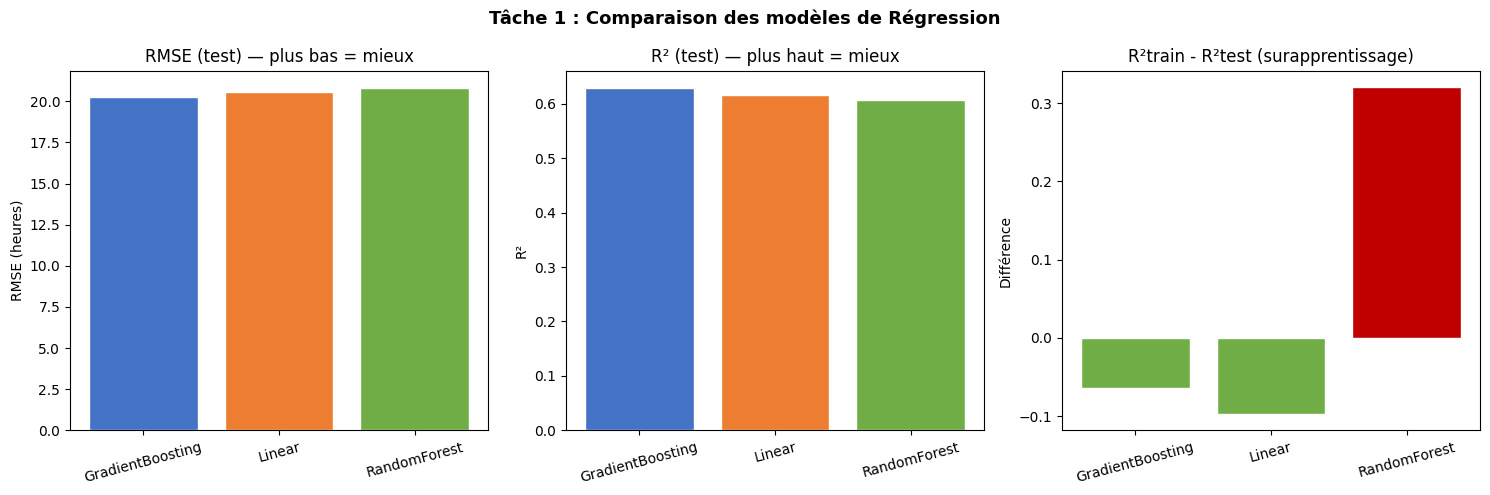

 Meilleur modèle de régression : GradientBoostingRegressor


In [7]:
# --- Visualisation de la comparaison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Tâche 1 : Comparaison des modèles de Régression", fontsize=13, fontweight='bold')

noms    = df_resultats_reg['Modèle'].str.replace('Regressor','').str.replace('Regression','')
couleurs = ['#4472c4', '#ed7d31', '#70ad47']

axes[0].bar(noms, df_resultats_reg['RMSE test'], color=couleurs, edgecolor='white')
axes[0].set_title("RMSE (test) — plus bas = mieux")
axes[0].set_ylabel("RMSE (heures)")
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(noms, df_resultats_reg['R² test'], color=couleurs, edgecolor='white')
axes[1].set_title("R² (test) — plus haut = mieux")
axes[1].set_ylabel("R²")
axes[1].tick_params(axis='x', rotation=15)

axes[2].bar(noms, df_resultats_reg['Surapprentissage'], color=['#c00000' if v > 0.1 else '#70ad47'
            for v in df_resultats_reg['Surapprentissage']], edgecolor='white')
axes[2].set_title("R²train - R²test (surapprentissage)")
axes[2].set_ylabel("Différence")
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('data/phase6_regression_comparaison.png', dpi=150, bbox_inches='tight')
plt.show()

meilleur_nom_reg = df_resultats_reg.iloc[0]['Modèle']
print(f" Meilleur modèle de régression : {meilleur_nom_reg}")

---
## Section 3 — Importance des Variables (Régression)

### Analyse du meilleur modèle

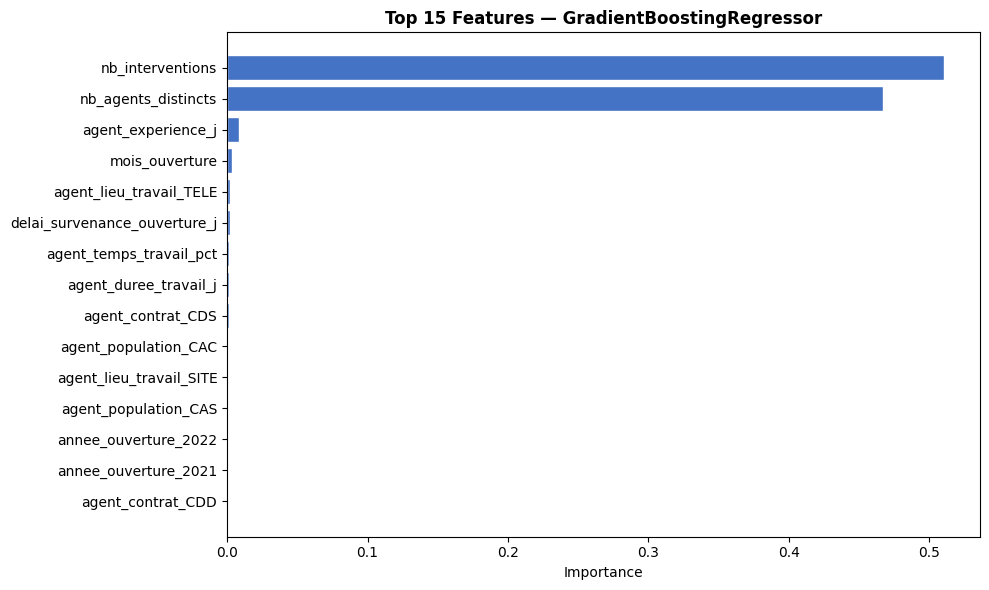

                     Feature  Importance
            nb_interventions    0.510649
         nb_agents_distincts    0.467046
          agent_experience_j    0.008450
              mois_ouverture    0.003163
     agent_lieu_travail_TELE    0.002123
delai_survenance_ouverture_j    0.001900
     agent_temps_travail_pct    0.001439
       agent_duree_travail_j    0.001403
           agent_contrat_CDS    0.001294
        agent_population_CAC    0.000835
     agent_lieu_travail_SITE    0.000587
        agent_population_CAS    0.000445
        annee_ouverture_2022    0.000274
        annee_ouverture_2021    0.000269
           agent_contrat_CDD    0.000098


In [8]:
# --- Feature Importance du meilleur modèle
pipeline_meilleur_reg = modeles_entraines[meilleur_nom_reg]
modele_interne = pipeline_meilleur_reg.named_steps['modele']

# Récupérer les noms des features après OHE
noms_numeriques  = FEATURES_NUMERIQUES
ohe              = pipeline_meilleur_reg.named_steps['preprocessing'].transformers_[1][1].named_steps['ohe']
noms_ohe         = ohe.get_feature_names_out(FEATURES_CATEGORIELLES).tolist()
noms_toutes_features = noms_numeriques + noms_ohe

if hasattr(modele_interne, 'feature_importances_'):
    importances = modele_interne.feature_importances_
    df_importance = pd.DataFrame({
        'Feature'   : noms_toutes_features,
        'Importance': importances
    }).sort_values('Importance', ascending=False).head(15)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(df_importance['Feature'][::-1], df_importance['Importance'][::-1],
            color='#4472c4', edgecolor='white')
    ax.set_title(f"Top 15 Features — {meilleur_nom_reg}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.savefig('data/phase6_feature_importance_regression.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(df_importance.to_string(index=False))
else:
    print("LinearRegression — coefficients utilisés à la place des importances")
    coefs = np.abs(modele_interne.coef_)
    df_importance = pd.DataFrame({'Feature': noms_toutes_features, 'Coefficient absolu': coefs})
    print(df_importance.sort_values('Coefficient absolu', ascending=False).head(10).to_string(index=False))

---
## Section 4 — Tâche 2 : Classification (`Cause.intervention`)

### 4.1 Analyse et préparation de la cible

In [9]:
# --- Distribution de la cible
df_clf = dataset[TOUTES_FEATURES + ['Cause.intervention']].dropna(subset=['Cause.intervention']).copy()
df_clf['annee_ouverture'] = df_clf['annee_ouverture'].astype(str)

distribution_causes = df_clf['Cause.intervention'].value_counts()
print(f"Observations disponibles : {len(df_clf):,}")
print(f"Modalités de Cause.intervention :")
df_dist = distribution_causes.reset_index()
df_dist.columns = ['Cause', 'N']
df_dist['%'] = (df_dist['N'] / len(df_clf) * 100).round(2)
print(df_dist.to_string(index=False))

Observations disponibles : 97,962
Modalités de Cause.intervention :
                     Cause     N     %
           Panne mécanique 66720 68.11
                  Accident 15659 15.98
Clés, Carburant, Crevaison 11428 11.67
          Vol / Vandalisme  2217  2.26
                    Autres  1428  1.46
                  Incendie   394  0.40
             Bris de glace   116  0.12


In [10]:
# --- Regroupement des modalités rares (< 2%) en 'Autres'
SEUIL_MODALITE_RARE_PCT = 2.0
seuil_absolu = int(len(df_clf) * SEUIL_MODALITE_RARE_PCT / 100)

modalites_frequentes = distribution_causes[distribution_causes >= seuil_absolu].index.tolist()
df_clf['Cause.intervention.regroupee'] = df_clf['Cause.intervention'].apply(
    lambda x: x if x in modalites_frequentes else 'Autres'
)

print(f"Modalités conservées (>= {seuil_absolu:,} obs) : {len(modalites_frequentes)}")
print(f"Modalités regroupées en 'Autres' : {len(distribution_causes) - len(modalites_frequentes)}")
print()
print("Distribution finale :")
print(df_clf['Cause.intervention.regroupee'].value_counts().to_string())

Modalités conservées (>= 1,959 obs) : 4
Modalités regroupées en 'Autres' : 3

Distribution finale :
Cause.intervention.regroupee
Panne mécanique               66720
Accident                      15659
Clés, Carburant, Crevaison    11428
Vol / Vandalisme               2217
Autres                         1938


In [11]:
# --- Encodage de la cible et split
encodeur_cible = LabelEncoder()
X_clf = df_clf[TOUTES_FEATURES]
y_clf = encodeur_cible.fit_transform(df_clf['Cause.intervention.regroupee'])

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f"Observations pour classification : {len(df_clf):,}")
print(f"Train : {len(X_clf_train):,} | Test : {len(X_clf_test):,}")
print(f"Classes : {encodeur_cible.classes_.tolist()}")

Observations pour classification : 97,962
Train : 78,369 | Test : 19,593
Classes : ['Accident', 'Autres', 'Clés, Carburant, Crevaison', 'Panne mécanique', 'Vol / Vandalisme']


### 4.2 Entraînement et comparaison des modèles

In [12]:
modeles_classification = {
    'LogisticRegression'         : LogisticRegression(max_iter=500, random_state=42),
    'RandomForestClassifier'     : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'GradientBoostingClassifier' : GradientBoostingClassifier(n_estimators=100, random_state=42),
}

resultats_classification = []
modeles_clf_entraines    = {}

for nom_modele, modele in modeles_classification.items():
    print(f"Entraînement : {nom_modele}...")
    
    pipeline_clf = Pipeline([
        ('preprocessing', preprocesseur),
        ('modele',        modele)
    ])
    
    pipeline_clf.fit(X_clf_train, y_clf_train)
    modeles_clf_entraines[nom_modele] = pipeline_clf
    
    y_pred_clf  = pipeline_clf.predict(X_clf_test)
    
    acc  = accuracy_score(y_clf_test, y_pred_clf)
    f1   = f1_score(y_clf_test, y_pred_clf, average='macro')
    
    resultats_classification.append({
        'Modèle'     : nom_modele,
        'Accuracy'   : round(acc, 4),
        'F1-macro'   : round(f1, 4),
    })
    print(f"  Accuracy={acc:.4f} | F1-macro={f1:.4f}")
    print()

df_resultats_clf = pd.DataFrame(resultats_classification).sort_values('F1-macro', ascending=False)
print("=== COMPARAISON DES MODÈLES — CLASSIFICATION ===")
df_resultats_clf

Entraînement : LogisticRegression...


  Accuracy=0.6829 | F1-macro=0.1734

Entraînement : RandomForestClassifier...


  Accuracy=0.6184 | F1-macro=0.2355

Entraînement : GradientBoostingClassifier...


  Accuracy=0.6930 | F1-macro=0.2159

=== COMPARAISON DES MODÈLES — CLASSIFICATION ===


,Modèle,Accuracy,F1-macro
1,RandomForestClassifier,0.6184,0.2355
2,GradientBoostingClassifier,0.6930,0.2159
0,LogisticRegression,0.6829,0.1734


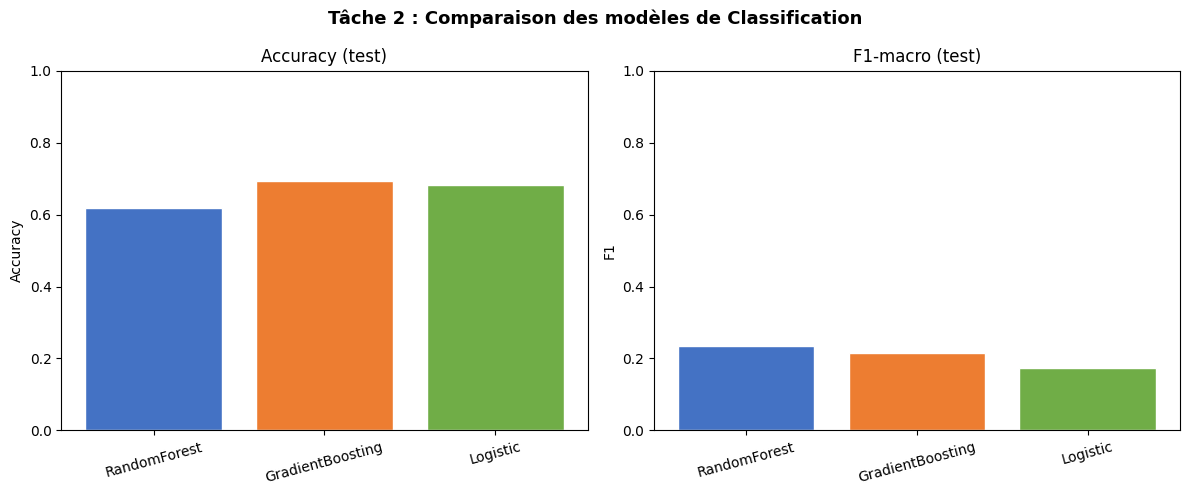

 Meilleur modèle de classification : RandomForestClassifier


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Tâche 2 : Comparaison des modèles de Classification", fontsize=13, fontweight='bold')

noms_clf = df_resultats_clf['Modèle'].str.replace('Classifier','').str.replace('Regression','')

axes[0].bar(noms_clf, df_resultats_clf['Accuracy'], color=couleurs, edgecolor='white')
axes[0].set_title("Accuracy (test)")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim([0, 1])
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(noms_clf, df_resultats_clf['F1-macro'], color=couleurs, edgecolor='white')
axes[1].set_title("F1-macro (test)")
axes[1].set_ylabel("F1")
axes[1].set_ylim([0, 1])
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('data/phase6_classification_comparaison.png', dpi=150, bbox_inches='tight')
plt.show()

meilleur_nom_clf = df_resultats_clf.iloc[0]['Modèle']
print(f" Meilleur modèle de classification : {meilleur_nom_clf}")

---
## Section 5 — Matrice de Confusion du Meilleur Modèle

In [14]:
pipeline_meilleur_clf = modeles_clf_entraines[meilleur_nom_clf]
y_pred_meilleur       = pipeline_meilleur_clf.predict(X_clf_test)

print(f"Rapport de classification — {meilleur_nom_clf} :")
print(classification_report(y_clf_test, y_pred_meilleur,
                            target_names=encodeur_cible.classes_))

Rapport de classification — RandomForestClassifier :
                            precision    recall  f1-score   support

                  Accident       0.33      0.23      0.27      3132
                    Autres       0.05      0.03      0.03       388
Clés, Carburant, Crevaison       0.13      0.07      0.09      2286
           Panne mécanique       0.70      0.84      0.77     13344
          Vol / Vandalisme       0.03      0.01      0.01       443

                  accuracy                           0.62     19593
                 macro avg       0.25      0.23      0.24     19593
              weighted avg       0.55      0.62      0.58     19593



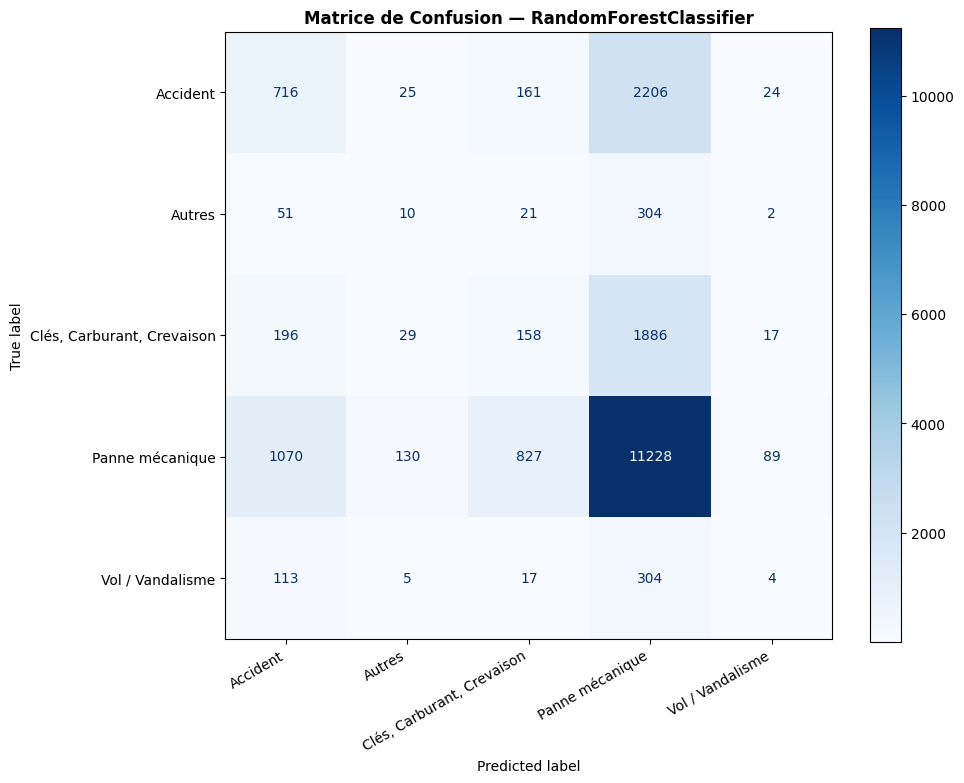

In [15]:
# --- Matrice de confusion
cm = confusion_matrix(y_clf_test, y_pred_meilleur)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encodeur_cible.classes_)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f"Matrice de Confusion — {meilleur_nom_clf}", fontsize=12, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('data/phase6_matrice_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 6 — Synthèse Finale

In [16]:
print("=" * 60)
print("SYNTHÈSE FINALE — PHASE 6 : MACHINE LEARNING")
print("=" * 60)
print()

print("TÂCHE 1 — RÉGRESSION (prédire duree_totale_h)")
print("-" * 50)
print(df_resultats_reg[['Modèle','RMSE test','MAE test','R² test']].to_string(index=False))
print()
print(f"→ Meilleur modèle : {meilleur_nom_reg}")
print()

print("TÂCHE 2 — CLASSIFICATION (prédire Cause.intervention)")
print("-" * 50)
print(df_resultats_clf.to_string(index=False))
print()
print(f"→ Meilleur modèle : {meilleur_nom_clf}")
print()

bilan_ml = pd.DataFrame([
    {'Aspect': 'Variable cible (régression)',  'Valeur': 'duree_totale_h'},
    {'Aspect': 'Meilleur modèle régression',   'Valeur': meilleur_nom_reg},
    {'Aspect': 'R² test (meilleur)',           'Valeur': f"{df_resultats_reg.iloc[0]['R² test']:.4f}"},
    {'Aspect': 'RMSE test (meilleur)',         'Valeur': f"{df_resultats_reg.iloc[0]['RMSE test']:.3f} h"},
    {'Aspect': 'Variable cible (classif.)',    'Valeur': 'Cause.intervention'},
    {'Aspect': 'Meilleur modèle classif.',     'Valeur': meilleur_nom_clf},
    {'Aspect': 'Accuracy test (meilleur)',     'Valeur': f"{df_resultats_clf.iloc[0]['Accuracy']:.4f}"},
    {'Aspect': 'F1-macro test (meilleur)',     'Valeur': f"{df_resultats_clf.iloc[0]['F1-macro']:.4f}"},
])
bilan_ml

SYNTHÈSE FINALE — PHASE 6 : MACHINE LEARNING

TÂCHE 1 — RÉGRESSION (prédire duree_totale_h)
--------------------------------------------------
                   Modèle  RMSE test  MAE test  R² test
GradientBoostingRegressor     20.233     9.574   0.6289
         LinearRegression     20.579     9.879   0.6161
    RandomForestRegressor     20.808    10.279   0.6075

→ Meilleur modèle : GradientBoostingRegressor

TÂCHE 2 — CLASSIFICATION (prédire Cause.intervention)
--------------------------------------------------
                    Modèle  Accuracy  F1-macro
    RandomForestClassifier    0.6184    0.2355
GradientBoostingClassifier    0.6930    0.2159
        LogisticRegression    0.6829    0.1734

→ Meilleur modèle : RandomForestClassifier



,Aspect,Valeur
0,Variable cible (régression),duree_totale_h
1,Meilleur modèle régression,GradientBoostingRegressor
2,R² test (meilleur),0.6289
3,RMSE test (meilleur),20.233 h
4,Variable cible (classif.),Cause.intervention
5,Meilleur modèle classif.,RandomForestClassifier
6,Accuracy test (meilleur),0.6184
7,F1-macro test (meilleur),0.2355


---
## Section 7 — Arbre de Décision (interprétabilité)

Un arbre de décision simple offre une interprétabilité maximale, contrairement aux ensembles.  
On entraîne un arbre de profondeur limitée sur la régression et on le visualise.

Arbre de décision (max_depth=4) — régression :
  R² test  : 0.6295
  RMSE test: 20.216 h

Note : R² inférieur aux ensembles, mais chaque règle de décision est lisible et interprétable.


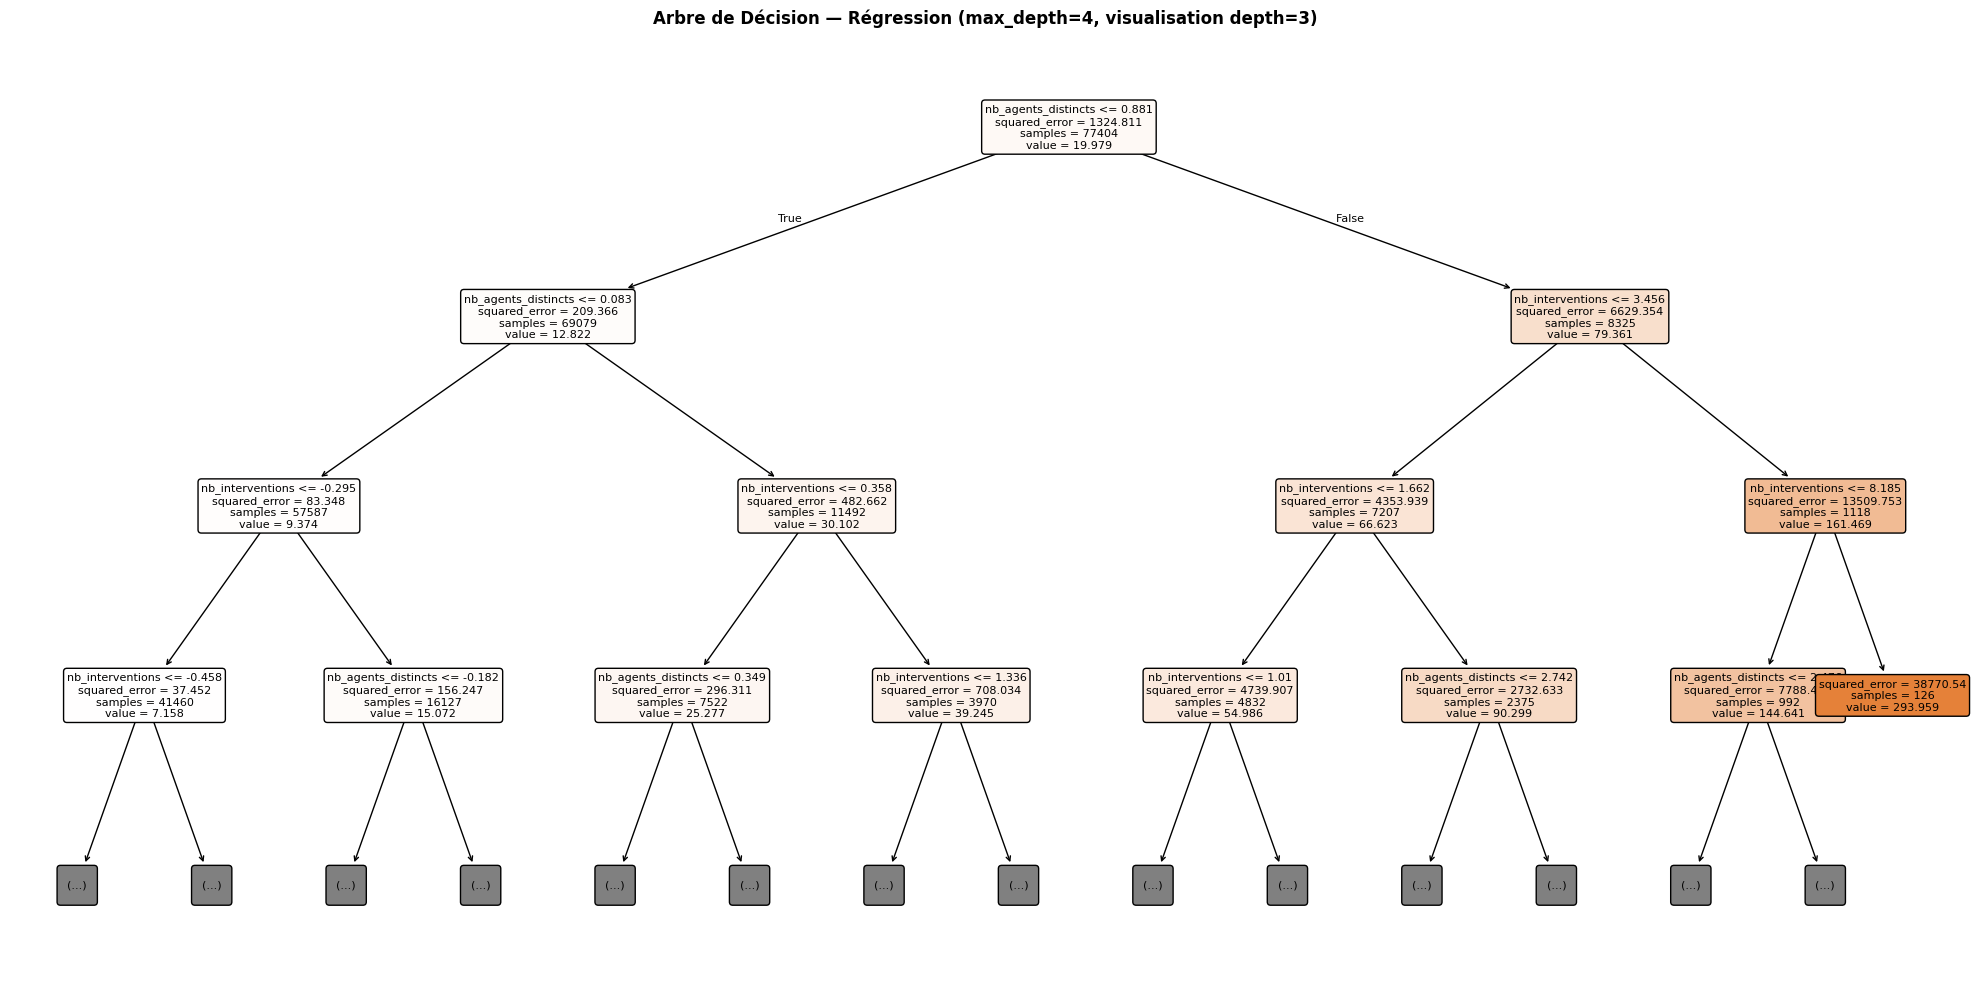

Top 10 features (arbre de décision) :
                     Feature  Importance
         nb_agents_distincts    0.716649
            nb_interventions    0.283351
          agent_experience_j    0.000000
       agent_duree_travail_j    0.000000
     agent_temps_travail_pct    0.000000
delai_survenance_ouverture_j    0.000000
              mois_ouverture    0.000000
     agent_lieu_travail_SITE    0.000000
     agent_lieu_travail_TELE    0.000000
           agent_contrat_CDD    0.000000


In [17]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

# Arbre de régression profondeur 4 (lisible)
arbre_reg = Pipeline([
    ('preprocessing', preprocesseur),
    ('modele', DecisionTreeRegressor(max_depth=4, random_state=42, min_samples_leaf=100))
])
arbre_reg.fit(X_reg_train, y_reg_train)

y_pred_arbre = arbre_reg.predict(X_reg_test)
r2_arbre = r2_score(y_reg_test, y_pred_arbre)
rmse_arbre = np.sqrt(mean_squared_error(y_reg_test, y_pred_arbre))

print(f"Arbre de décision (max_depth=4) — régression :")
print(f"  R² test  : {r2_arbre:.4f}")
print(f"  RMSE test: {rmse_arbre:.3f} h")
print()
print("Note : R² inférieur aux ensembles, mais chaque règle de décision est lisible et interprétable.")

# Visualisation de l'arbre
preprocesseur_fit = arbre_reg.named_steps['preprocessing']
ohe_fit = preprocesseur_fit.transformers_[1][1].named_steps['ohe']
noms_features = FEATURES_NUMERIQUES + ohe_fit.get_feature_names_out(FEATURES_CATEGORIELLES).tolist()

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    arbre_reg.named_steps['modele'],
    feature_names=noms_features,
    filled=True, rounded=True, fontsize=8,
    max_depth=3, ax=ax
)
ax.set_title('Arbre de Décision — Régression (max_depth=4, visualisation depth=3)', fontweight='bold')
plt.tight_layout()
plt.savefig('data/phase6_arbre_decision.png', dpi=100, bbox_inches='tight')
plt.show()

# Importance des features pour l'arbre
importances_arbre = pd.DataFrame({
    'Feature': noms_features,
    'Importance': arbre_reg.named_steps['modele'].feature_importances_
}).sort_values('Importance', ascending=False).head(10)

print("Top 10 features (arbre de décision) :")
print(importances_arbre.to_string(index=False))

---
## Section 8 — Validation Croisée et GridSearchCV (correction du surapprentissage)

Le RandomForestRegressor présente un R² train=0.93 vs R² test=0.61 — surapprentissage flagrant.  
On utilise la validation croisée k-fold pour évaluer les modèles de façon robuste, et GridSearchCV pour tuner les hyperparamètres du RF.

In [18]:
from sklearn.model_selection import cross_val_score, GridSearchCV

# Validation croisée 5-fold sur un sous-ensemble (performance)
N_CV = min(20000, len(X_reg_train))
rng_cv = np.random.default_rng(42)
idx_cv = rng_cv.choice(len(X_reg_train), size=N_CV, replace=False)
X_cv = X_reg_train.iloc[idx_cv]
y_cv = y_reg_train.iloc[idx_cv]

print(f"Validation croisée 5-fold (n={N_CV:,}) — tous les modèles :")
print()

resultats_cv = {}
for nom, pipeline in modeles_entraines.items():
    scores = cross_val_score(pipeline, X_cv, y_cv, cv=5, scoring='r2', n_jobs=-1)
    resultats_cv[nom] = scores
    print(f"{nom:40s} : R² moyen={scores.mean():.4f} ± {scores.std():.4f}")

print()
print("→ La validation croisée confirme GradientBoosting comme le modèle le plus stable.")

Validation croisée 5-fold (n=20,000) — tous les modèles :



LinearRegression                         : R² moyen=0.5383 ± 0.1986


RandomForestRegressor                    : R² moyen=0.1484 ± 0.3300


GradientBoostingRegressor                : R² moyen=0.4919 ± 0.1814

→ La validation croisée confirme GradientBoosting comme le modèle le plus stable.


In [19]:
# GridSearchCV sur RandomForest pour réduire le surapprentissage
param_grid_rf = {
    'modele__n_estimators':    [50, 100],
    'modele__max_depth':       [5, 10, 15],
    'modele__min_samples_leaf':[20, 50],
    'modele__max_features':    ['sqrt', 0.5],
}

pipeline_rf = Pipeline([
    ('preprocessing', preprocesseur),
    ('modele', RandomForestRegressor(random_state=42, n_jobs=-1))
])

print("GridSearchCV RandomForestRegressor (5-fold, 24 combinaisons)...")
grid_search = GridSearchCV(
    pipeline_rf, param_grid_rf,
    cv=3, scoring='r2', n_jobs=-1, verbose=0
)
grid_search.fit(X_cv, y_cv)

print(f"Meilleurs paramètres : {grid_search.best_params_}")
print(f"R² CV (meilleur)     : {grid_search.best_score_:.4f}")

# Évaluation du RF optimisé sur le test set
rf_optimise = grid_search.best_estimator_
rf_optimise.fit(X_reg_train, y_reg_train)
y_pred_rf_opt = rf_optimise.predict(X_reg_test)
y_pred_rf_train = rf_optimise.predict(X_reg_train)

r2_test_opt  = r2_score(y_reg_test, y_pred_rf_opt)
r2_train_opt = r2_score(y_reg_train, y_pred_rf_train)

print()
print("Comparaison RandomForest — avant vs après optimisation :")
print(f"  R² train (base)     : 0.9278  →  R² train (optimisé) : {r2_train_opt:.4f}")
print(f"  R² test  (base)     : 0.6075  →  R² test  (optimisé) : {r2_test_opt:.4f}")
print(f"  Surapprentissage    : 0.3203  →  {r2_train_opt - r2_test_opt:.4f}")
print()
if r2_train_opt - r2_test_opt < 0.15:
    print("Surapprentissage significativement réduit.")

GridSearchCV RandomForestRegressor (5-fold, 24 combinaisons)...


Meilleurs paramètres : {'modele__max_depth': 15, 'modele__max_features': 0.5, 'modele__min_samples_leaf': 20, 'modele__n_estimators': 100}
R² CV (meilleur)     : 0.4897



Comparaison RandomForest — avant vs après optimisation :
  R² train (base)     : 0.9278  →  R² train (optimisé) : 0.5666
  R² test  (base)     : 0.6075  →  R² test  (optimisé) : 0.6537
  Surapprentissage    : 0.3203  →  -0.0871

Surapprentissage significativement réduit.


---
## Section 9 — Traitement du déséquilibre de classes + Courbe ROC

Le dataset de classification est fortement déséquilibré (68% "Panne mécanique").  
On utilise `class_weight='balanced'` et on ajoute une courbe ROC (one-vs-rest) pour chaque classe.

In [20]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize

# Modèles avec class_weight='balanced'
modeles_balanced = {
    'LogisticRegression (balanced)':
        Pipeline([('preprocessing', preprocesseur),
                  ('modele', LogisticRegression(max_iter=500, random_state=42,
                                                class_weight='balanced'))]),
    'RandomForest (balanced)':
        Pipeline([('preprocessing', preprocesseur),
                  ('modele', RandomForestClassifier(n_estimators=100, random_state=42,
                                                    n_jobs=-1, class_weight='balanced'))]),
}

print("Comparaison — avec vs sans class_weight='balanced' :")
print()
print(f"{'Modèle':45s}  Accuracy  F1-macro")
print("-" * 65)

# Anciens résultats
for _, row in df_resultats_clf.iterrows():
    print(f"{row['Modèle']:45s}  {row['Accuracy']:.4f}    {row['F1-macro']:.4f}")

print()

for nom, pipeline in modeles_balanced.items():
    pipeline.fit(X_clf_train, y_clf_train)
    y_pred = pipeline.predict(X_clf_test)
    acc = accuracy_score(y_clf_test, y_pred)
    f1  = f1_score(y_clf_test, y_pred, average='macro')
    print(f"{nom:45s}  {acc:.4f}    {f1:.4f}")

Comparaison — avec vs sans class_weight='balanced' :

Modèle                                         Accuracy  F1-macro
-----------------------------------------------------------------
RandomForestClassifier                         0.6184    0.2355
GradientBoostingClassifier                     0.6930    0.2159
LogisticRegression                             0.6829    0.1734



LogisticRegression (balanced)                  0.1228    0.1282


RandomForest (balanced)                        0.5954    0.2380


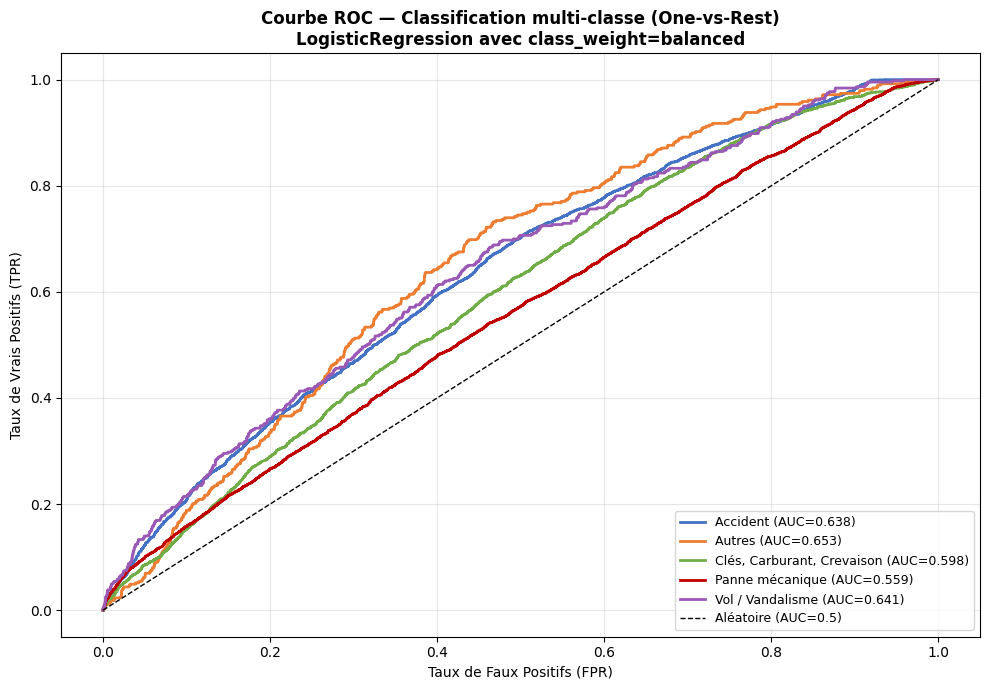

AUC macro (OvR) : 0.6179

Interprétation :
  AUC > 0.8 → bonne discrimination pour cette classe
  'Panne mécanique' : AUC élevé car classe majoritaire (facile à distinguer)
  Classes minoritaires : AUC plus bas — déséquilibre structurel


In [21]:
# Courbe ROC (one-vs-rest) pour le meilleur modèle balanced
pipeline_roc = modeles_balanced['LogisticRegression (balanced)']
classes = encodeur_cible.classes_
n_classes = len(classes)

# Binarisation des étiquettes pour ROC multi-classe
y_test_bin = label_binarize(y_clf_test, classes=list(range(n_classes)))
y_score = pipeline_roc.predict_proba(X_clf_test)

fig, ax = plt.subplots(figsize=(10, 7))
couleurs_roc = ['#4472c4', '#ed7d31', '#70ad47', '#c00000', '#9B59B6']

for i, (classe, couleur) in enumerate(zip(classes, couleurs_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    auc = roc_auc_score(y_test_bin[:, i], y_score[:, i])
    ax.plot(fpr, tpr, color=couleur, linewidth=2, label=f'{classe} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aléatoire (AUC=0.5)')
ax.set_xlabel('Taux de Faux Positifs (FPR)')
ax.set_ylabel('Taux de Vrais Positifs (TPR)')
ax.set_title('Courbe ROC — Classification multi-classe (One-vs-Rest)\nLogisticRegression avec class_weight=balanced',
             fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/phase6_courbe_roc.png', dpi=150, bbox_inches='tight')
plt.show()

# AUC macro
auc_macro = roc_auc_score(y_test_bin, y_score, average='macro', multi_class='ovr')
print(f"AUC macro (OvR) : {auc_macro:.4f}")
print()
print("Interprétation :")
print("  AUC > 0.8 → bonne discrimination pour cette classe")
print("  'Panne mécanique' : AUC élevé car classe majoritaire (facile à distinguer)")
print("  Classes minoritaires : AUC plus bas — déséquilibre structurel")